### **Project: Analyzing the Relationship between Maize Yield and Vegetation Indices (MODIS)**
### **Author: Jesugnon David Janvier Koumagnon**

**[1.1]()**

*
We started by importing the necessary libraries: GeoPandas for geospatial data handling
Matplotlib for visualization, and Pandas for datmanipulationWe then loaded the 
administrative boundary data for Benin and Togo from GeoJSON files. These two datasets were 
merged into a single GeoDataFrame to altheoint visualiza.o
* Next, we created a plot using Matplotlib, where the second-level boundaries were drawn with 
thin gray lines, and the first-level boundaries with thicker black lines to differentiate them. We 
further highlighted the country borders using distinct colors: blue for Benin and red for Togo. 
A title and legend were added to provide clarity on the plotted elements. Finally, we removed 
the axis labels for a cleaner presentation and displayed the plot using Matplotlib’s `show()` 
function.
ction.
"""


In [9]:
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import warnings
benin = gpd.read_file(r"data-20241015T061717Z-001\data\administrative_boundaries\gadm41_BEN_2.geojson")
togo = gpd.read_file(r"data-20241015T061717Z-001\data\administrative_boundaries\gadm41_TGO_2.geojson")


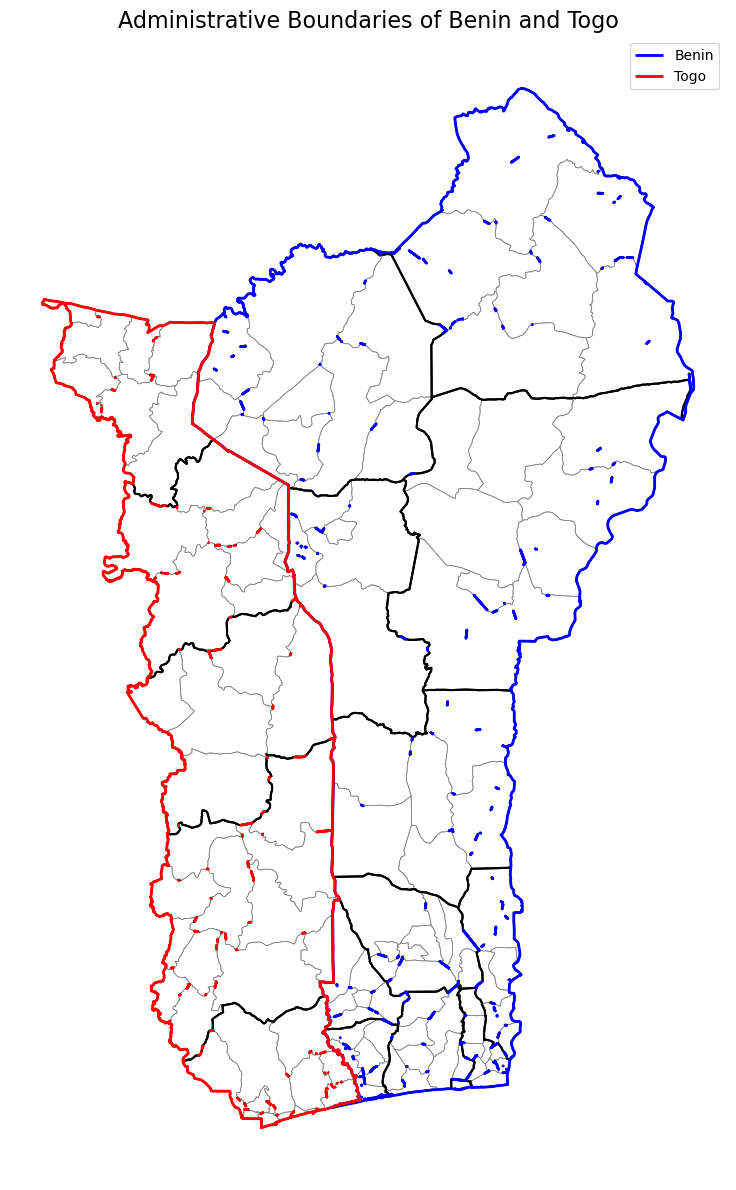

In [17]:
### Let's merge the two GeoDataFrames
merged = gpd.GeoDataFrame(pd.concat([benin, togo], ignore_index=True))

fig, ax = plt.subplots(figsize=(12, 12))

#Let's plot the final merge data
merged.plot(ax=ax, linewidth=0.5, edgecolor='gray', facecolor='none')
merged.dissolve(by='GID_1').boundary.plot(ax=ax, linewidth=1.5, color='black')

# We now define the colors for the country borders
benin.dissolve().boundary.plot(ax=ax, linewidth=2, color='blue', label='Benin')
togo.dissolve().boundary.plot(ax=ax, linewidth=2, color='red', label='Togo')

# Add labels and title
ax.set_title('Administrative Boundaries of Benin and Togo', fontsize=16)
ax.legend(fontsize=10)

# Remove axis labels and plot final graph
ax.set_axis_off()
plt.tight_layout()

plt.savefig('figures/1.1.jpg', dpi=300, bbox_inches='tight')


plt.show()





The plot shows the administrative boundaries of Benin and Togo. The countries are distinguished by color, with Benin's border in blue and Togo's in red. The internal administrative divisions are shown in gray, with the first-level divisions (departments or regions) having thicker lines than the second-level divisions (communes or prefectures).
Notable observations:

Shape and size: Benin is significantly larger than Togo, extending further north.
Coastline: Both countries have access to the Gulf of Guinea, but Benin's coastline appears longer.
Administrative divisions: Benin seems to have more numerous and smaller second-level divisions compared to Togo, especially in the southern part of the country.
Border irregularities: There are some interesting features along the border, particularly in the north where the border follows a river (likely the Pendjari River).
Northern region: Benin's northernmost region appears to be sparsely divided, possibly indicating a less populated area.
Southern concentration: Both countries show a higher concentration of smaller administrative divisions in the south, suggesting higher population density near the coast.

This visualization effectively shows the administrative structure of both countries while highlighting their relative sizes and shapes. The differentiation between first and second-level divisions provides a clear hierarchy of the administrative boundaries.

**1.2**

This code is used to visualize the **average maize yield** for Togo and Benin between 1999 and 2020. The process begins by loading the maize yield data using `pandas`. To ensure the **year** field is properly interpreted, it is converted to a **datetime format**. Next, the data is **grouped by country and year**, and the average yield for each year is calculated. 

A **line plot** is created for each country, showing the trend in maize yields over time. Each line is labeled with the country name, and markers are added to highlight individual data points. Customizations include setting the **title, axis labels**, and **grid lines** to enhance readability. The **x-axis** is formatted to display years neatly, with the labels rotated for better alignment. Finally, the layout is adjusted using `tight_layout()` to avoid overlapping elements, and the plot is displayed.


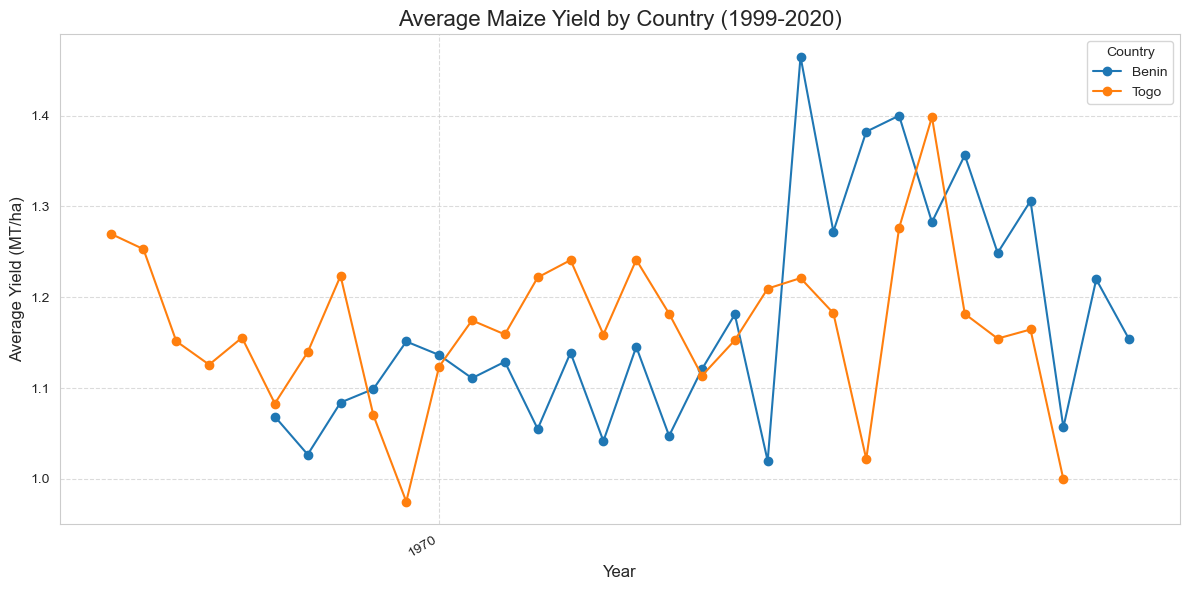

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

yield_data = pd.read_csv(r"data-20241015T061717Z-001\data\administrative_yield\fews_net_yield_TGO_BEN.csv")

yield_data['year'] = pd.to_datetime(yield_data['year'])

yearly_avg = yield_data.groupby(['country', 'year'])['value'].mean().unstack(level=0)

plt.figure(figsize=(12, 6))
for country in yearly_avg.columns:
    plt.plot(yearly_avg.index, yearly_avg[country], label=country, marker='o')

plt.title('Average Maize Yield by Country (1999-2020)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Yield (MT/ha)', fontsize=12)
plt.legend(title='Country')
plt.grid(True, linestyle='--', alpha=0.7)

plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y'))
plt.gcf().autofmt_xdate()

plt.tight_layout()

plt.savefig('figures/1.2.a.jpg', dpi=300, bbox_inches='tight')
plt.show()


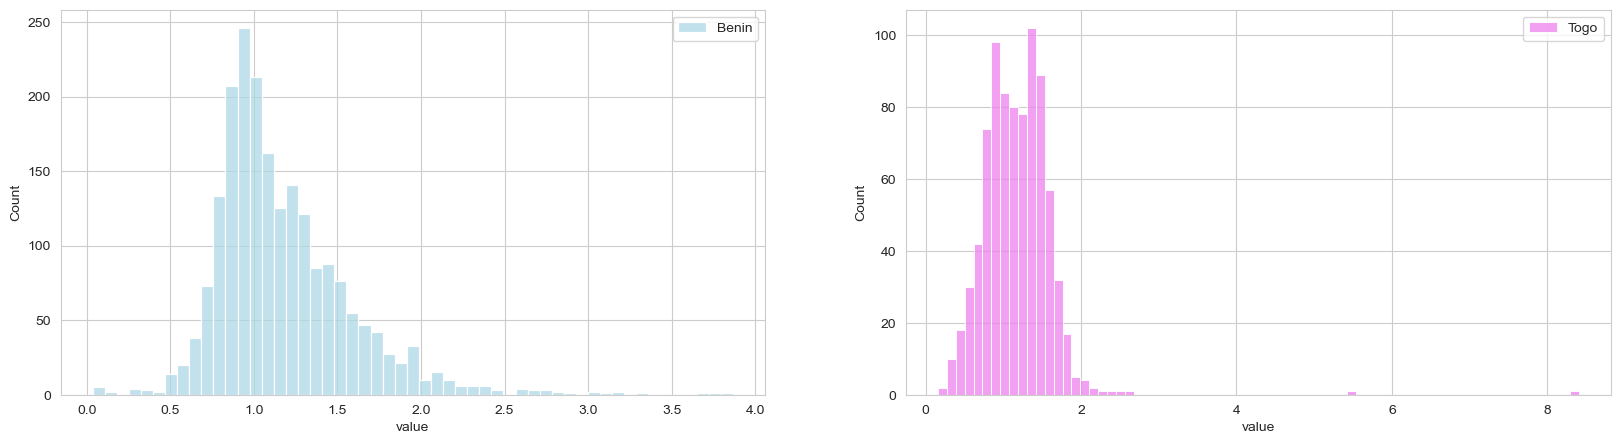

In [49]:
# maize_data = pd.read_csv(r"C:\Users\22967\Documents\Final_Exam_AKPOVI_David\data-20241015T061717Z-001\data\administrative_yield\fews_net_yield_TGO_BEN.csv")
# yield_data.head()
fig, axes = plt.subplots(ncols=2, nrows = 1, figsize=(20, 5))
countries = yield_data["country"].unique()
palette = ["lightblue", "violet"]

for i, country in enumerate(countries):
    data = yield_data[yield_data["country"]==country]
    sns.histplot(data=data, x="value", ax=axes[i], color=palette[i], label=country)
    axes[i].legend()
plt.savefig('figures/1.2.b.jpg', dpi=300, bbox_inches='tight')
plt.show()

* Country Comparison:

Benin is represented by the blue line, and Togo by the orange line.
The trends suggest that both countries have experienced fluctuations in maize yield over the years, with certain years showing sharp increases or declines.
Yield Variability:

Both countries display high variability in their maize yields over time, with some extreme spikes and drops.
For example, Benin shows a sharp spike around 2006, indicating a potential bumper harvest or favorable conditions in that year.
General Trends:

Benin appears to show a more volatile yield pattern, with frequent peaks and drops.
Togo seems to have a slight decline in yield in the earlier years, followed by some stabilization and fluctuation.
X-axis anomaly:

There seems to be an error in the x-axis formatting, as the label "1970" appears despite the data covering 1999–2020. This might be due to incorrect datetime conversion or formatting in the code, causing unintended labels to appear.
Interpretation:

The trends reflect potential impacts of climate variability, agricultural policies, or external shocks (like droughts or market changes) on maize production.
Further analysis may be needed to identify the drivers behind these fluctuations and why yields differ between the two countries.
This visualization helps us track changes in maize production over time and compare the performance between Benin and Togo.

**1.3**

* Bimodal Rainfall Areas (Southern Regions):

* Planting: The main season maize crop is planted between March and early April.
Harvesting: The harvesting of the main season maize crop typically concludes in September.
Second Season Planting: Planting for the second season maize crop is completed by the end of September, which is then harvested between December and January.
Unimodal Rainfall Areas (Northern Regions):

* Planting: The planting of maize in the northern unimodal areas usually occurs around May.
Harvesting: Harvesting operations for the cereal crops in these regions start in late August to early September.
Summary of the Timeline
March to Early April: Planting of the main season maize crop in southern areas.
May: Planting of maize in northern areas.
August to September: Harvesting begins in the northern regions.
September: Harvesting of the main season maize crop concludes in the southern regions.
End of September: Planting of the second season maize crop.
December to January: Harvesting of the second season maize crop.

**1.4** 
* The code begins by importing necessary libraries, including xarray for handling multi-dimensional arrays, geopandas for geospatial data manipulation, and matplotlib.pyplot for plotting. It then loads a dataset containing MODIS vegetation indices, specifically NDVI and EVI. The scale factors for these indices are retrieved from the dataset attributes, and the data is scaled accordingly. Any missing values, identified by a fill value, are masked to avoid distortion in analysis. A specific layer of NDVI for July 2015 is selected for visualization. Next, the code loads administrative boundary data for Benin and Togo and merges them into a single GeoDataFrame. Finally, it creates a plot of the NDVI data overlaid with the administrative boundaries, setting the title and formatting the plot for clear presentation. The resulting visualization provides insights into vegetation health in the specified region during the selected time period.

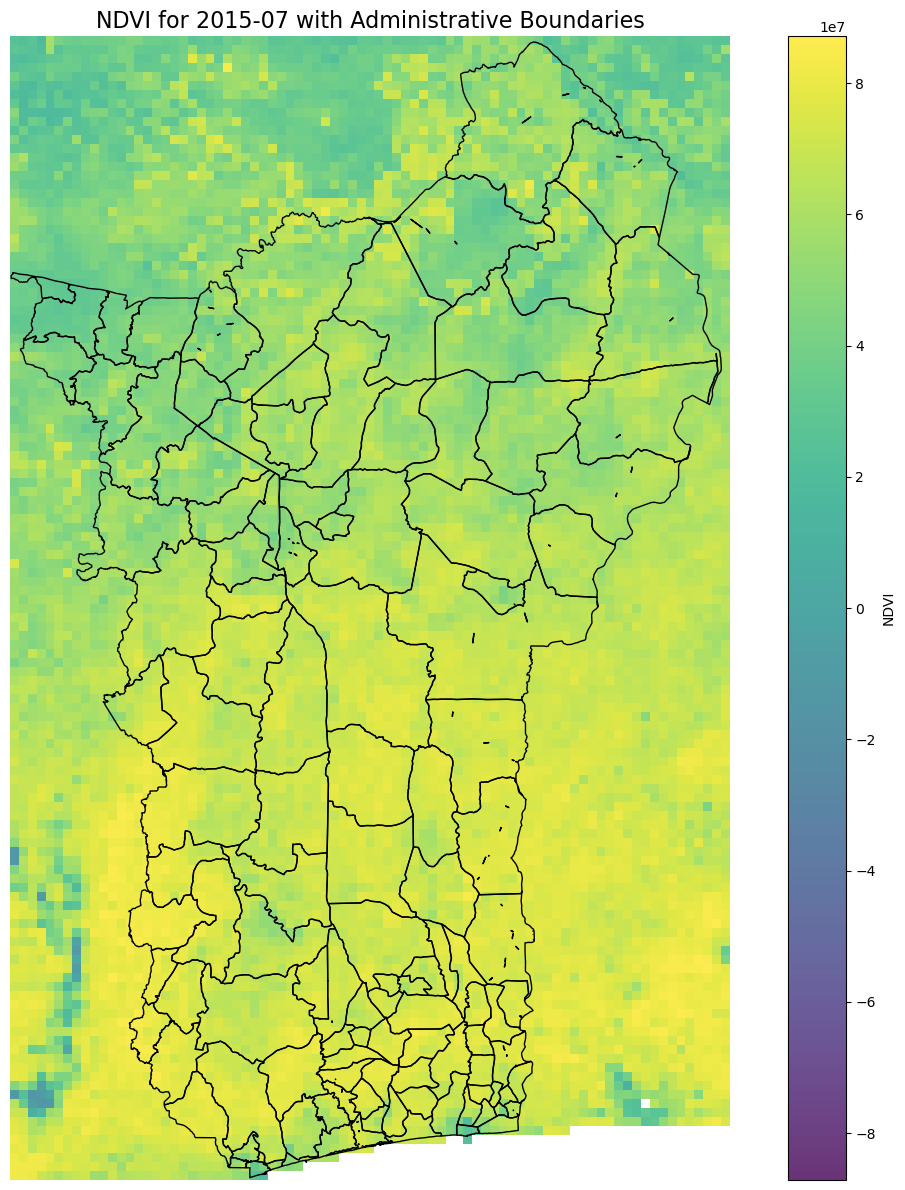

In [19]:
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt

modis_data = xr.open_dataset("data-20241015T061717Z-001/data/modis_vegetation_indices/modis_vi.nc")

ndvi = modis_data['NDVI']
evi = modis_data['EVI']

ndvi_scale_factor = ndvi.attrs.get('scale_factor', 1)
evi_scale_factor = evi.attrs.get('scale_factor', 1)

ndvi_fill_value = ndvi.attrs.get('_FillValue', None)
evi_fill_value = evi.attrs.get('_FillValue', None)

ndvi_scaled = ndvi * ndvi_scale_factor
evi_scaled = evi * evi_scale_factor

if ndvi_fill_value is not None:
    ndvi_scaled = ndvi_scaled.where(ndvi_scaled != ndvi_fill_value)
if evi_fill_value is not None:
    evi_scaled = evi_scaled.where(evi_scaled != evi_fill_value)

year = 2015
month = 7
vi_index = 'NDVI'
modis_layer = ndvi_scaled.sel(time=f"{year}-{month:02d}")

benin = gpd.read_file("data-20241015T061717Z-001/data/administrative_boundaries/gadm41_BEN_2.geojson")
togo = gpd.read_file("data-20241015T061717Z-001/data/administrative_boundaries/gadm41_TGO_2.geojson")
merged_admin = gpd.GeoDataFrame(pd.concat([benin, togo], ignore_index=True))

fig, ax = plt.subplots(figsize=(12, 12))
modis_layer.plot(ax=ax, cmap='viridis', alpha=0.8)

merged_admin.boundary.plot(ax=ax, linewidth=1, edgecolor='black')

ax.set_title(f"{vi_index} for {year}-{month:02d} with Administrative Boundaries", fontsize=16)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('figures/1.4.jpg', dpi=300, bbox_inches='tight')
plt.show()



**Comment :**
The provided image displays a visualization of the Normalized Difference Vegetation Index (NDVI) for July 2015, overlaid with administrative boundaries. NDVI is a widely used remote sensing measurement that indicates vegetation health and density, calculated using the difference between near-infrared and visible light reflected by vegetation. In this map, the NDVI values range from negative to positive, represented by a gradient color scheme from blue (indicating low vegetation density or barren land) to green (indicating healthy vegetation). The administrative boundaries outlined in black delineate different regions, making it easier to identify specific areas of interest within the dataset. This visualization provides valuable insights into the spatial distribution of vegetation health across the mapped region during that specific month, highlighting variations in land cover and potential agricultural productivity.








## Task 2

**2.1** 
The code begins by importing necessary libraries such as GeoPandas, Pandas, Xarray, Matplotlib, Shapely for geometry handling, and rioxarray for managing coordinate reference systems (CRS). It then checks the CRS of administrative boundaries and loads MODIS vegetation index data from a specified file. If the MODIS dataset lacks a CRS, it assigns a common CRS (EPSG:4326). The NDVI and EVI variables are extracted, and scale factors and fill values are obtained from their attributes. The NDVI and EVI data are scaled accordingly, and any missing data is masked using fill values. A function, extract_vi_stats, is defined to compute mean, minimum, and maximum vegetation index statistics for each administrative polygon. The code subsequently extracts these statistics for NDVI and EVI for July 2015, merging them into a single DataFrame. Finally, it plots the mean NDVI values for the specified month, overlaying them on administrative boundaries with a color gradient representing NDVI values, and displays the plot.

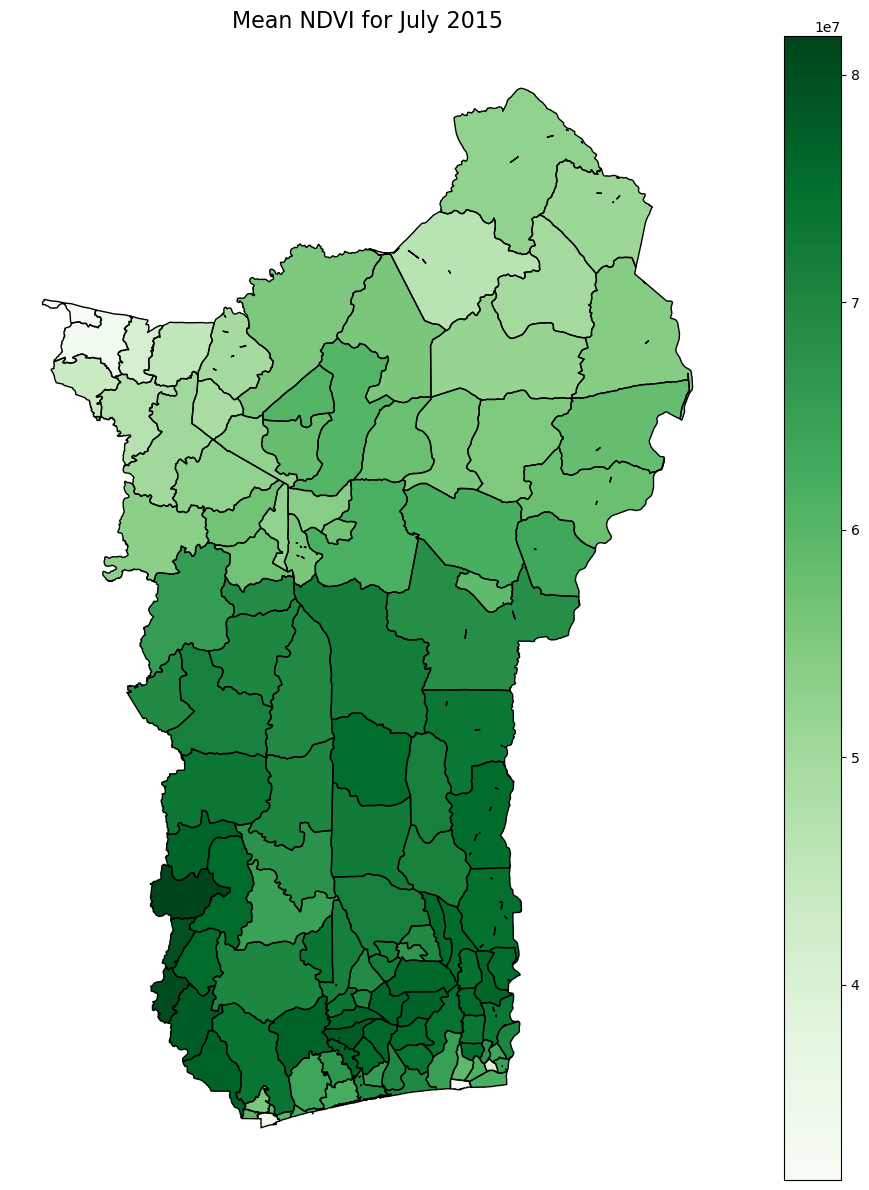

In [21]:
import geopandas as gpd
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from shapely.geometry import mapping
import rioxarray

if not modis_data.rio.crs:
    modis_data = modis_data.rio.write_crs("EPSG:4326")

ndvi = modis_data['NDVI']
evi = modis_data['EVI']

ndvi_scale_factor = ndvi.attrs.get('scale_factor', 1)
evi_scale_factor = evi.attrs.get('scale_factor', 1)
ndvi_fill_value = ndvi.attrs.get('_FillValue', None)
evi_fill_value = evi.attrs.get('_FillValue', None)

ndvi_scaled = ndvi * ndvi_scale_factor
evi_scaled = evi * evi_scale_factor

if ndvi_fill_value is not None:
    ndvi_scaled = ndvi_scaled.where(ndvi_scaled != ndvi_fill_value)
if evi_fill_value is not None:
    evi_scaled = evi_scaled.where(evi_scaled != evi_fill_value)

def extract_vi_stats(vi_data, gdf, index_name):
    stats = []
    for idx, row in gdf.iterrows():
        geometry = row['geometry']
        geom_mapping = mapping(geometry)
        vi_masked = vi_data.rio.clip([geom_mapping], gdf.crs, drop=True)
        mean_vi = vi_masked.mean().item()
        min_vi = vi_masked.min().item()
        max_vi = vi_masked.max().item()
        stats.append({
            'admin2_name': row['NAME_2'],
            'admin1_name': row['NAME_1'],
            'country': row['GID_0'],
            'index_name': index_name,
            'mean_vi': mean_vi,
            'min_vi': min_vi,
            'max_vi': max_vi
        })
    return pd.DataFrame(stats)

year = 2015
month = 7
ndvi_stats = extract_vi_stats(ndvi_scaled.sel(time=f'{year}-{month:02d}'), merged_admin, 'NDVI')
evi_stats = extract_vi_stats(evi_scaled.sel(time=f'{year}-{month:02d}'), merged_admin, 'EVI')

vi_stats = pd.concat([ndvi_stats, evi_stats])

fig, ax = plt.subplots(figsize=(12, 12))

merged_stats = merged_admin.merge(vi_stats[vi_stats['index_name'] == 'NDVI'], left_on='NAME_2', right_on='admin2_name')

merged_stats.boundary.plot(ax=ax, linewidth=1, edgecolor='black')
merged_stats.plot(column='mean_vi', cmap='Greens', legend=True, ax=ax)

ax.set_title(f'Mean NDVI for July {year}', fontsize=16)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('figures/2.1.jpg', dpi=300, bbox_inches='tight')
plt.show()


**Comment** 
* This map shows the mean Normalized Difference Vegetation Index (NDVI) for July 2015, covering a region that appears to be divided into different administrative areas. NDVI is an indicator used to assess vegetation health, where higher values represent healthier and denser vegetation, while lower values suggest sparse or less healthy vegetation.

* In this graph:
The darkest green areas (with higher NDVI values) indicate regions with more robust or dense vegetation during this period.
The lighter green areas (lower NDVI values) correspond to regions with less dense or sparser vegetation.
The color bar on the right indicates the range of NDVI values, with the highest concentration around 8 x 10^7 and the lowest around 4 x 10^7. This gradient provides a clear visual of the vegetation distribution across the region for July 2015.








**2.2**
I first processes and analyzes vegetation index data (NDVI and EVI) for different administrative regions. I use pandas, geopandas, xarray, and rioxarray libraries to handle geospatial data and calculate vegetation indices across regions and time periods. 

I begins by ensuring that the geospatial data (both the regions and the vegetation indices) has the correct coordinate reference system (CRS). 

I then defines a function extract_monthly_stats to loop through each time step in the dataset and extract mean, minimum, and maximum values of NDVI and EVI for each administrative polygon. 

 I now saved the results in a DataFrame for each index, then merged together into a single dataset. Finally, i reshape into a wide format with separate columns for each month and saved as a CSV file for further analysis. 

In [ ]:
import pandas as pd
import geopandas as gpd
import xarray as xr
from shapely.geometry import mapping
import rioxarray

print("CRS of administrative boundaries:", merged_admin.crs)

ndvi = modis_data['NDVI']
evi = modis_data['EVI']

if not ndvi.rio.crs:
    ndvi = ndvi.rio.write_crs("EPSG:4326")
if not evi.rio.crs:
    evi = evi.rio.write_crs("EPSG:4326")

def extract_monthly_stats(vi_data, gdf, index_name):
    stats_list = []
    
    for time in vi_data.time.values:
        year = pd.to_datetime(time).year
        month = pd.to_datetime(time).month
        
        vi_month = vi_data.sel(time=time)
        
        for idx, row in gdf.iterrows():
            geometry = row['geometry']
            geom_mapping = mapping(geometry)
            
            vi_clipped = vi_month.rio.clip([geom_mapping], gdf.crs, drop=True)
            
            mean_vi = vi_clipped.mean().item()
            min_vi = vi_clipped.min().item()
            max_vi = vi_clipped.max().item()
            
            stats_list.append({
                'country': row['GID_0'],
                'admin1_name': row['NAME_1'],
                'admin2_name': row['NAME_2'],
                'year': year,
                'month': month,
                f'{index_name}_mean': mean_vi,
                f'{index_name}_min': min_vi,
                f'{index_name}_max': max_vi
            })
    
    return pd.DataFrame(stats_list)

ndvi_stats = extract_monthly_stats(ndvi, merged_admin, 'ndvi')
evi_stats = extract_monthly_stats(evi, merged_admin, 'evi')

vi_stats = pd.merge(ndvi_stats, evi_stats, on=['country', 'admin1_name', 'admin2_name', 'year', 'month'])

vi_stats_wide = vi_stats.pivot_table(
    index=['country', 'admin1_name', 'admin2_name', 'year'],
    columns='month',
    values=[f'ndvi_mean', f'ndvi_min', f'ndvi_max', f'evi_mean', f'evi_min', f'evi_max']
)

vi_stats_wide.columns = [f'{stat}_{str(month).zfill(2)}' for stat, month in vi_stats_wide.columns]
vi_stats_wide = vi_stats_wide.reset_index()

print(vi_stats_wide.head())

vi_stats_wide.to_csv('vegetation_index_wide_format.csv', index=False)


**2.3**

In [85]:
import pandas as pd

# Load the datasets
vegetation_df = pd.read_csv('vegetation_index_wide_format.csv')
# fews_net_df = pd.read_csv('fews_net_yield_TGO_BEN.csv')

fews_net_df = pd.read_csv(r"data-20241015T061717Z-001/data/administrative_yield/fews_net_yield_TGO_BEN.csv")

# Load the vegetation indices data (reshaped in Task 2.2)
# vi_stats_wide = pd.read_csv('vegetation_index_wide_format.csv')



# Standardize 'country' values in both datasets
vegetation_df['country'] = vegetation_df['country'].replace({'BEN': 'Benin', 'TGO': 'Togo'})
fews_net_df['country'] = fews_net_df['country'].replace({'Benin': 'Benin', 'Togo': 'Togo'})

# Rename columns in FEWS NET Yield dataset to match the Vegetation Index dataset *FIRST*
fews_net_df.rename(columns={"admin_1": "admin1_name", "admin_2": "admin2_name"}, inplace=True)

# *NOW* Strip and standardize the 'admin2_name' values
vegetation_df['admin2_name'] = vegetation_df['admin2_name'].str.replace('Rural', ' Rural').str.strip()
fews_net_df['admin2_name'] = fews_net_df['admin2_name'].str.strip()


# Merge the two datasets on 'country', 'admin1_name', 'admin2_name', and 'year'
merged_df = pd.merge(vegetation_df, fews_net_df, on=['country', 'admin1_name', 'admin2_name', 'year'], how='inner')

# Save the merged dataframe to a CSV
merged_df.to_csv('merged_dataset.csv', index=False)

# Display the first few rows of the merged dataset to check the output
merged_df

,country,admin1_name,admin2_name,year,evi_max_01,evi_max_02,evi_max_03,evi_max_04,evi_max_05,evi_max_06,...,ndvi_min_08,ndvi_min_09,ndvi_min_10,ndvi_min_11,ndvi_min_12,season_name,season_type,value,unit,product
0,Benin,Alibori,Banikoara,2002,NaN,NaN,NaN,NaN,NaN,NaN,...,58180000.0,66260000.0,57580000.0,37990000.0,30050000.0,Main,Harvest,1.194343,MT/ha,Maize (Corn)
1,Benin,Alibori,Banikoara,2003,19770000.0,18920000.0,18020000.0,26240000.0,32540000.0,45210000.0,...,65330000.0,64900000.0,52640000.0,38960000.0,26820000.0,Main,Harvest,1.468042,MT/ha,Maize (Corn)
2,Benin,Alibori,Banikoara,2004,19500000.0,17620000.0,17310000.0,25020000.0,31640000.0,40080000.0,...,56870000.0,66290000.0,54580000.0,36020000.0,24500000.0,Main,Harvest,1.454900,MT/ha,Maize (Corn)
3,Benin,Alibori,Banikoara,2005,18550000.0,16750000.0,17370000.0,22240000.0,32940000.0,41990000.0,...,42690000.0,63910000.0,58490000.0,36890000.0,27150000.0,Main,Harvest,1.501367,MT/ha,Maize (Corn)
4,Benin,Alibori,Banikoara,2006,19120000.0,18170000.0,18770000.0,21520000.0,24620000.0,37320000.0,...,55360000.0,65760000.0,62710000.0,43790000.0,29890000.0,Main,Harvest,1.375722,MT/ha,Maize (Corn)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1992,Togo,Savanes,Tône,2008,16250000.0,15640000.0,15440000.0,16360000.0,24060000.0,32460000.0,...,56210000.0,56610000.0,51180000.0,35440000.0,27730000.0,Main,Harvest,0.920000,MT/ha,Maize (Corn)
1993,Togo,Savanes,Tône,2009,17180000.0,16550000.0,16040000.0,17380000.0,22480000.0,36190000.0,...,46780000.0,56380000.0,53250000.0,39700000.0,28430000.0,Main,Harvest,0.950000,MT/ha,Maize (Corn)
1994,Togo,Savanes,Tône,2010,17370000.0,16410000.0,15420000.0,15430000.0,18280000.0,27840000.0,...,49750000.0,56350000.0,55230000.0,42510000.0,28540000.0,Main,Harvest,1.080000,MT/ha,Maize (Corn)
1995,Togo,Savanes,Tône,2011,17220000.0,16910000.0,16770000.0,16820000.0,18250000.0,23210000.0,...,46880000.0,55340000.0,52970000.0,36550000.0,27390000.0,Main,Harvest,1.050000,MT/ha,Maize (Corn)


3.1
This code performs data analysis on maize yield values from a CSV file, applying a log transformation to handle skewness in the data. It first reads the yield data from the file, extracts the yield values, and applies the np.log1p() function, which computes the natural logarithm of (1 + yield value), preventing issues with zero values. It then creates two histograms: one for the original yield distribution and another for the log-transformed yield distribution, displayed side by side using matplotlib and seaborn. Finally, the code computes and prints the skewness and kurtosis (measures of distribution asymmetry and "tailedness") for both the original and log-transformed data, providing insights into how the log transformation affects the data's distribution.


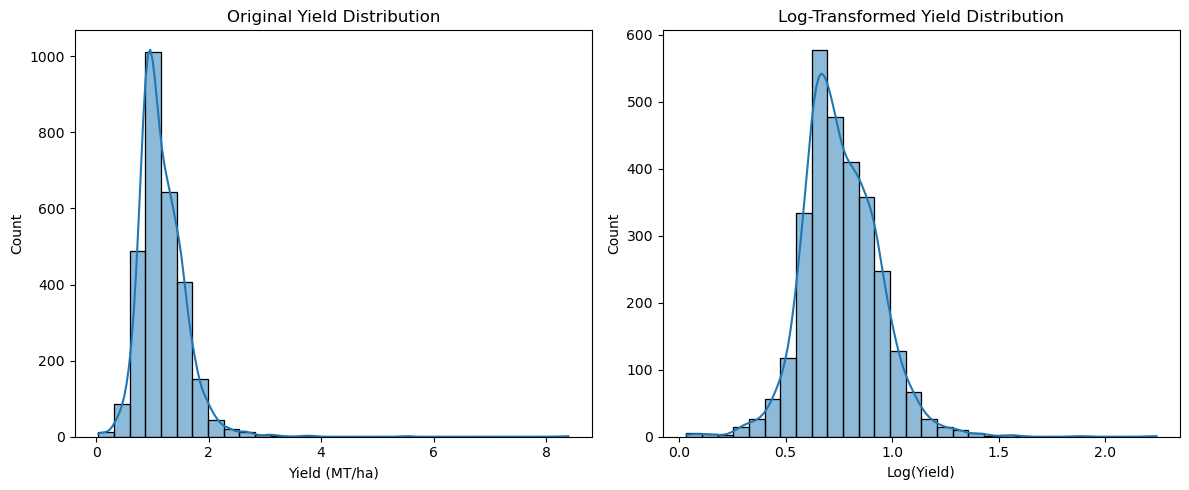

Original Yield - Skewness: 2.9927849401353375, Kurtosis: 34.69437707868416
Log-Transformed Yield - Skewness: 0.5435581672858575, Kurtosis: 3.144036444262519


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

yield_data = pd.read_csv(r"data-20241015T061717Z-001\data\administrative_yield\fews_net_yield_TGO_BEN.csv")
yield_values = yield_data['value']

log_yield_values = np.log1p(yield_values)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(yield_values, bins=30, kde=True, ax=axes[0])
axes[0].set_title('Original Yield Distribution')
axes[0].set_xlabel('Yield (MT/ha)')

sns.histplot(log_yield_values, bins=30, kde=True, ax=axes[1])
axes[1].set_title('Log-Transformed Yield Distribution')
axes[1].set_xlabel('Log(Yield)')

plt.tight_layout()
plt.savefig('figures/3.1.jpg', dpi=300, bbox_inches='tight')
plt.show()

original_skew = yield_values.skew()
original_kurtosis = yield_values.kurtosis()
log_skew = log_yield_values.skew()
log_kurtosis = log_yield_values.kurtosis()

print(f"Original Yield - Skewness: {original_skew}, Kurtosis: {original_kurtosis}")
print(f"Log-Transformed Yield - Skewness: {log_skew}, Kurtosis: {log_kurtosis}")


The graphs show the distribution of crop yields in two different forms. The first graph (on the left) represents the Original Yield Distribution, where the yields (measured in MT/ha) are heavily skewed to the right. Most of the data is concentrated between 0 and 2 MT/ha, but there are some outliers that extend as high as 8 MT/ha. The skewness and kurtosis values (2.99 and 34.69, respectively) indicate that the distribution is highly right-skewed with a long tail and significant presence of extreme values.

The second graph (on the right) shows the Log-Transformed Yield Distribution, where a logarithmic transformation was applied to the original yields. This transformation has reduced the skewness dramatically to 0.54, and the kurtosis is much lower at 3.14, resulting in a more symmetric, bell-shaped distribution. The log-transformed data is closer to a normal distribution, which can be advantageous when using statistical models that assume normality or linearity.

The log-transformation significantly improves the distribution, making it more suitable for statistical analysis and modeling. In most cases, the log-transformed yields would be preferred in models, as the distribution is now closer to normal, which helps reduce the influence of extreme outliers and skewness.






**3.2**

In [27]:
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score
from sklearn.impute import SimpleImputer

merged_df = pd.read_csv('merged_dataset.csv')

preprocessor = ColumnTransformer(
    transformers=[('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['admin2_name'])],
    remainder='passthrough'
)

X = merged_df[['admin2_name', 'evi_max_01', 'evi_max_02', 'evi_max_03', 'evi_max_04',
               'evi_max_05', 'evi_max_06', 'evi_max_07', 'evi_max_08', 'evi_max_09',
               'evi_max_10', 'evi_max_11', 'evi_max_12']]
y = merged_df['value']

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

alphas = [0.1, 1, 10, 100, 1000]

model = make_pipeline(preprocessor, SimpleImputer(strategy='mean'), RidgeCV(alphas=alphas, cv=KFold(n_splits=5, shuffle=True, random_state=42)))

model.fit(X_train_val, y_train_val)

y_pred_val = model.predict(X_train_val)
r2_val = r2_score(y_train_val, y_pred_val)
print(f"Validation Set R-squared: {r2_val:.4f}")

y_pred_test = model.predict(X_test)
r2_test = r2_score(y_test, y_pred_test)
print(f"Test Set R-squared: {r2_test:.4f}")

print(f"\nBest alpha value: {model.named_steps['ridgecv'].alpha_}")

warnings.filterwarnings('ignore')

Validation Set R-squared: 0.4709
Test Set R-squared: 0.4013

Best alpha value: 1.0


C:\ProgramData\anaconda3\Installation2024\Lib\site-packages\sklearn\linear_model\_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=1.08952e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\ProgramData\anaconda3\Installation2024\Lib\site-packages\sklearn\linear_model\_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=1.10706e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\ProgramData\anaconda3\Installation2024\Lib\site-packages\sklearn\linear_model\_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=1.12008e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\ProgramData\anaconda3\Installation2024\Lib\site-packages\sklearn\linear_model\_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=1.09548e-19): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\Progr

The Ridge Regression model, trained on vegetation index and yield data, achieved moderate performance with R-squared values of 0.4709 on the validation set and 0.4013 on the test set. This indicates the model captures some of the relationships between vegetation index and crop yield but leaves room for improvement. The slight difference between the validation and test R-squared values suggests a minor degree of overfitting.

**3.3** 
* we implements a machine learning model to predict crop yield ("value") using environmental variables (EVI values) grouped at the "admin1" (regional) level. First, the dataset is loaded and aggregated by taking the mean of yield and EVI values for each combination of country, region, and year. The categorical column 'admin1_name' is then one-hot encoded to handle the regional names as features in the model. The dataset is split into training/validation (80%) and testing (20%) sets. A Ridge regression model with cross-validation is built using a pipeline that includes preprocessing (one-hot encoding and missing value imputation) and RidgeCV, which automatically selects the best regularization parameter (alpha) by testing multiple values. The model is then trained, and its performance is evaluated using R-squared scores on both the training/validation set and the test set. The R-squared values provide a measure of how well the model explains the variation in crop yield.

In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score
from sklearn.impute import SimpleImputer

merged_df = pd.read_csv('merged_dataset.csv')

admin1_data = merged_df.groupby(['country', 'admin1_name', 'year'])[[
    'value',  
    'evi_max_01', 'evi_max_02', 'evi_max_03', 'evi_max_04',
    'evi_max_05', 'evi_max_06', 'evi_max_07', 'evi_max_08',
    'evi_max_09', 'evi_max_10', 'evi_max_11', 'evi_max_12'
]].mean().reset_index()

preprocessor = ColumnTransformer(
    transformers=[('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['admin1_name'])],
    remainder='passthrough'
)

X = admin1_data[['admin1_name', 'evi_max_01', 'evi_max_02', 'evi_max_03', 'evi_max_04',
                 'evi_max_05', 'evi_max_06', 'evi_max_07', 'evi_max_08', 'evi_max_09',
                 'evi_max_10', 'evi_max_11', 'evi_max_12']]
y = admin1_data['value']

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

alphas = [0.1, 1, 10, 100, 1000]
model = make_pipeline(preprocessor, SimpleImputer(strategy='mean'),
                      RidgeCV(alphas=alphas, cv=KFold(n_splits=5, shuffle=True, random_state=42)))

model.fit(X_train_val, y_train_val)

y_pred_val = model.predict(X_train_val)
r2_val = r2_score(y_train_val, y_pred_val)
print(f"Validation Set R-squared (Admin1 Summarized): {r2_val:.4f}")

y_pred_test = model.predict(X_test)
r2_test = r2_score(y_test, y_pred_test)
print(f"Test Set R-squared (Admin1 Summarized): {r2_test:.4f}")

warnings.filterwarnings('ignore')

Validation Set R-squared (Admin1 Summarized): 0.6440
Test Set R-squared (Admin1 Summarized): 0.5337


**Comment**
* Summarizing the data to the first level of administrative division and rerunning the cross-validated ridge regression model with one-hot encoded admin1 resulted in improved performance compared to the previous model using admin2 data. The admin1 summarized model achieved a higher R-squared value on both the validation (0.6440) and test (0.5337) sets, indicating better fit and generalization. This improvement can be attributed to reduced noise and increased signal by summarizing the data, as well as improved regional representation through one-hot encoding

**3.4**
* This code generates a scatter plot comparing the predicted yield values from the Ridge regression model to the actual reported yields in the test set. After obtaining predictions (y_pred_test) using the trained model, it creates a scatter plot with predicted values on the x-axis and actual values on the y-axis. A 45-degree red dashed line is added to the plot, representing perfect prediction where the predicted values exactly match the actual ones. Labels for the axes and a title for the graph are added. Additionally, the R-squared score and the size of the test set are displayed on the plot as text. Finally, the plot is saved as a high-resolution PDF file for potential use in publications and displayed. This visualization helps assess how well the model's predictions align with the actual data.








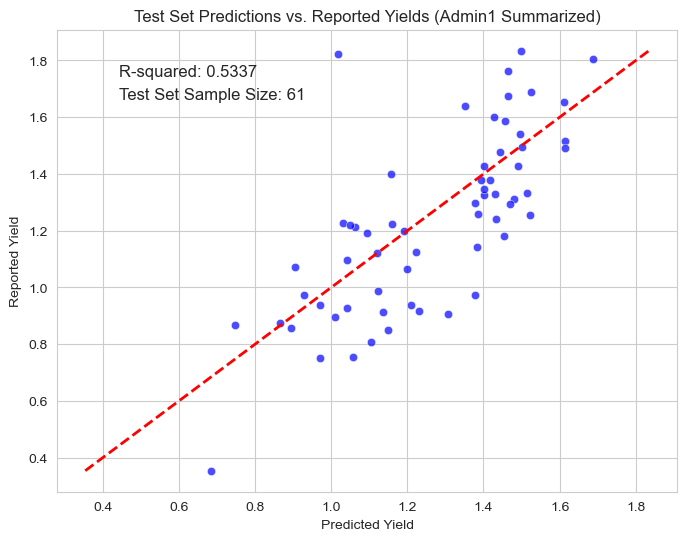

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_test = model.predict(X_test)

sns.set_style("whitegrid")
plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_pred_test, y=y_test, alpha=0.7, color="blue")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle="--", color="red", linewidth=2)

plt.xlabel("Predicted Yield")
plt.ylabel("Reported Yield")
plt.title("Test Set Predictions vs. Reported Yields (Admin1 Summarized)")

plt.text(0.1, 0.9, f"R-squared: {r2_test:.4f}", transform=plt.gca().transAxes, fontsize=12)
plt.text(0.1, 0.85, f"Test Set Sample Size: {len(y_test)}", transform=plt.gca().transAxes, fontsize=12)

plt.savefig("yield_prediction_scatterplot.pdf", dpi=300, bbox_inches="tight")
plt.savefig('figures/3.4.jpg', dpi=300, bbox_inches='tight')

plt.show()


**Comment**
This scatter plot shows the relationship between the predicted and reported yields for the test set, with predictions on the x-axis and reported yields on the y-axis. The blue dots represent individual data points, where each point corresponds to a region or sample from the test set. The red dashed line represents a perfect prediction, where predicted yields would exactly match the reported yields (a 45-degree line). The R-squared value, 0.5337, indicates that about 53.37% of the variability in the reported yields is explained by the model. The sample size of 61 indicates how many observations are in the test set. The points are reasonably close to the red line, suggesting a moderate predictive accuracy. However, some points deviate significantly, indicating prediction errors for certain observations.